In [1]:

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import scipy.stats as st
import missingno as msno
import pycountry
import plotly.express as px
import geopandas as gpd

pd.set_option('display.max_columns', None)


In [2]:
# Changing the default working folder path


import os

# Change the default working folder once
os.chdir(r"C:\Users\shahu\EDUCATION\data")  # absolute path

# Get current working directory
cwd = os.getcwd()
print("Current working directory:", cwd)

# List all files and folders
files = os.listdir(cwd)
print("Files and folders:", files)

Current working directory: C:\Users\shahu\EDUCATION\data
Files and folders: ['choice and conso of indicators.xlsx', 'corr_flat_table.csv', 'corr_flat_table_1.csv', 'EdStatsCountry.csv', 'EdStatsCountrySeries.csv', 'EdStatsData.csv', 'EdStatsFootNote.csv', 'EdStatsSeries.csv', 'fill_rate_per_group.csv', 'fill_rate_per_group_1.csv', 'Indicators.xlsx', 'missing_matrix.png', '~$choice and conso of indicators.xlsx']


# Indicator Data D


""
### Description

The `EdStatsSeries` table contains data about indicators, with the following variables:
- `Series Code`: Unique identifier for each indicator series.
- `Topic`: Category or theme of the indicator (to be dropped).
- `Indicator Name`: Name/description of the indicator.

For further analysis, only `Series Code` and `Indicator Name` are relevant.
The `Topic` variable will be dropped as other variables.
"""


In [3]:
indicator_data = pd.read_csv('EdStatsSeries.csv')
indicator_data.head()


,Series Code,Topic,Indicator Name,Short definition,Long definition,Unit of measure,Periodicity,Base Period,Other notes,Aggregation method,Limitations and exceptions,Notes from original source,General comments,Source,Statistical concept and methodology,Development relevance,Related source links,Other web links,Related indicators,License Type,Unnamed: 20
0,BAR.NOED.1519.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15-19 with...,Percentage of female population age 15-19 with...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BAR.NOED.1519.ZS,Attainment,Barro-Lee: Percentage of population age 15-19 ...,Percentage of population age 15-19 with no edu...,Percentage of population age 15-19 with no edu...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BAR.NOED.15UP.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15+ with n...,Percentage of female population age 15+ with n...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BAR.NOED.15UP.ZS,Attainment,Barro-Lee: Percentage of population age 15+ wi...,Percentage of population age 15+ with no educa...,Percentage of population age 15+ with no educa...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BAR.NOED.2024.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 20-24 with...,Percentage of female population age 20-24 with...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
indicator_data.shape

(3665, 21)

In [5]:
print(indicator_data.duplicated().sum())

0


In [6]:
indicator_data.drop_duplicates().reset_index()

,index,Series Code,Topic,Indicator Name,Short definition,Long definition,Unit of measure,Periodicity,Base Period,Other notes,Aggregation method,Limitations and exceptions,Notes from original source,General comments,Source,Statistical concept and methodology,Development relevance,Related source links,Other web links,Related indicators,License Type,Unnamed: 20
0,0,BAR.NOED.1519.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15-19 with...,Percentage of female population age 15-19 with...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,BAR.NOED.1519.ZS,Attainment,Barro-Lee: Percentage of population age 15-19 ...,Percentage of population age 15-19 with no edu...,Percentage of population age 15-19 with no edu...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,BAR.NOED.15UP.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15+ with n...,Percentage of female population age 15+ with n...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,BAR.NOED.15UP.ZS,Attainment,Barro-Lee: Percentage of population age 15+ wi...,Percentage of population age 15+ with no educa...,Percentage of population age 15+ with no educa...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,BAR.NOED.2024.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 20-24 with...,Percentage of female population age 20-24 with...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3660,3660,UIS.XUNIT.USCONST.3.FSGOV,Expenditures,Government expenditure per upper secondary stu...,NaN,"Average total (current, capital and transfers)...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNESCO Institute for Statistics,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3661,3661,UIS.XUNIT.USCONST.4.FSGOV,Expenditures,Government expenditure per post-secondary non-...,NaN,"Average total (current, capital and transfers)...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNESCO Institute for Statistics,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3662,3662,UIS.XUNIT.USCONST.56.FSGOV,Expenditures,Government expenditure per tertiary student (c...,NaN,"Average total (current, capital and transfers)...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNESCO Institute for Statistics,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3663,3663,XGDP.23.FSGOV.FDINSTADM.FFD,Expenditures,Government expenditure in secondary institutio...,"Total general (local, regional and central) go...","Total general (local, regional and central) go...",NaN,NaN,NaN,Secondary,NaN,NaN,NaN,NaN,UNESCO Institute for Statistics,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
indicator_data.dtypes

Series Code                             object
Topic                                   object
Indicator Name                          object
Short definition                        object
Long definition                         object
Unit of measure                        float64
Periodicity                             object
Base Period                             object
Other notes                             object
Aggregation method                      object
Limitations and exceptions              object
Notes from original source             float64
General comments                        object
Source                                  object
Statistical concept and methodology     object
Development relevance                   object
Related source links                    object
Other web links                        float64
Related indicators                     float64
License Type                           float64
Unnamed: 20                            float64
dtype: object

In [8]:
missing_data = indicator_data.isna().mean().sort_values(ascending=False)
print(missing_data)

Unnamed: 20                            1.000000
Notes from original source             1.000000
License Type                           1.000000
Related indicators                     1.000000
Other web links                        1.000000
Unit of measure                        1.000000
Development relevance                  0.999181
General comments                       0.996180
Limitations and exceptions             0.996180
Statistical concept and methodology    0.993724
Aggregation method                     0.987176
Periodicity                            0.972988
Related source links                   0.941337
Base Period                            0.914325
Other notes                            0.849386
Short definition                       0.411733
Topic                                  0.000000
Source                                 0.000000
Long definition                        0.000000
Indicator Name                         0.000000
Series Code                            0

In [9]:
indicator_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3665 entries, 0 to 3664
Data columns (total 21 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Series Code                          3665 non-null   object 
 1   Topic                                3665 non-null   object 
 2   Indicator Name                       3665 non-null   object 
 3   Short definition                     2156 non-null   object 
 4   Long definition                      3665 non-null   object 
 5   Unit of measure                      0 non-null      float64
 6   Periodicity                          99 non-null     object 
 7   Base Period                          314 non-null    object 
 8   Other notes                          552 non-null    object 
 9   Aggregation method                   47 non-null     object 
 10  Limitations and exceptions           14 non-null     object 
 11  Notes from original source    

In [10]:
indicator_data.describe()

,Unit of measure,Notes from original source,Other web links,Related indicators,License Type,Unnamed: 20
count,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# deleting columns with missing values and unnecessary columns through judgement

columns_tokeep = ['Series Code','Indicator Name']
indicator_data = indicator_data[columns_tokeep]
indicator_data.head()

,Series Code,Indicator Name
0,BAR.NOED.1519.FE.ZS,Barro-Lee: Percentage of female population age...
1,BAR.NOED.1519.ZS,Barro-Lee: Percentage of population age 15-19 ...
2,BAR.NOED.15UP.FE.ZS,Barro-Lee: Percentage of female population age...
3,BAR.NOED.15UP.ZS,Barro-Lee: Percentage of population age 15+ wi...
4,BAR.NOED.2024.FE.ZS,Barro-Lee: Percentage of female population age...


### Processing

In this step, **only the chosen indicators of interest** will be selected from the `indicators_values` dataframe. This filtering ensures that the analysis focuses exclusively on the **relevant indicators**, excluding any unnecessary or unrelated data.


In [12]:
# Read the Excel file
indicator_list = pd.read_excel("Indicators.xlsx")

# Make sure to extract the list of Series Codes
codes_to_keep = indicator_list["Series Code"].unique().tolist()

# Filter indicator_data based on the codes
indicator_data = indicator_data[indicator_data["Series Code"].isin(codes_to_keep)]

print(indicator_data)

                Series Code                                     Indicator Name
610          IT.CMP.PCMP.P2                Personal computers (per 100 people)
611          IT.NET.USER.P2                    Internet users (per 100 people)
1658         NY.GDP.MKTP.CD                                  GDP (current US$)
1659         NY.GDP.MKTP.KD                            GDP (constant 2010 US$)
1662         NY.GDP.PCAP.CD                       GDP per capita (current US$)
1930      PRJ.POP.1519.3.MF  Projection: Population age 15-19 in thousands ...
1933      PRJ.POP.1519.4.MF  Projection: Population age 15-19 in thousands ...
2298         SE.SEC.ENRL.GC  Enrolment in secondary general, both sexes (nu...
2307            SE.SEC.ENRR   Gross enrolment ratio, secondary, both sexes (%)
2332            SE.TER.ENRL  Enrolment in tertiary education, all programme...
2376      SE.XPD.SECO.PC.ZS  Government expenditure per secondary student a...
2378      SE.XPD.TERT.PC.ZS  Government expenditure 

# country_indicator D

""
### Description
This table contains records of indicator implementations by country, with the following columns:
- **`country_code`**: Unique identifier for each country.
- **`series_code`**: Unique identifier for each indicator (matches the `series_code` in the `stat_series` table).
- **`year`**: Year the indicator was implemented in the country.
- **`description`**: Likely a note or context about the implementation (e.g., details or conditions).






- The table appears to track **which indicators (`series_code`) have been implemented in each country (`country_code`) and the corresponding year**.
- At this stage, this table does not seem immediately useful for the current analysis, as the focus is on indicator metadata rather than country-specific implementation timelines.
""



In [13]:
country_indicator= pd.read_csv('EdStatsFootNote.csv')
country_indicator.head()


,CountryCode,SeriesCode,Year,DESCRIPTION,Unnamed: 4
0,ABW,SE.PRE.ENRL.FE,YR2001,Country estimation.,NaN
1,ABW,SE.TER.TCHR.FE,YR2005,Country estimation.,NaN
2,ABW,SE.PRE.TCHR.FE,YR2000,Country estimation.,NaN
3,ABW,SE.SEC.ENRL.GC,YR2004,Country estimation.,NaN
4,ABW,SE.PRE.TCHR,YR2006,Country estimation.,NaN


In [14]:
country_indicator.shape

(643638, 5)

In [15]:
missing_values = country_indicator.isna().mean().sort_values(ascending=False)
print(missing_values)

Unnamed: 4     1.0
CountryCode    0.0
SeriesCode     0.0
Year           0.0
DESCRIPTION    0.0
dtype: float64


In [16]:
country_indicator.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 643638 entries, 0 to 643637
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   CountryCode  643638 non-null  object 
 1   SeriesCode   643638 non-null  object 
 2   Year         643638 non-null  object 
 3   DESCRIPTION  643638 non-null  object 
 4   Unnamed: 4   0 non-null       float64
dtypes: float64(1), object(4)
memory usage: 24.6+ MB


In [17]:
country_indicator.describe()

,Unnamed: 4
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


# indicator_values D

"""
## Data Overview: Indicator Values Table

### Description
This table provides **time-series data** for indicators by country, including:
- **`country`**: Name or code of the country.
- **`indicator_name`**: Name of the indicator.
- **`indicator_code`**: Unique identifier for the indicator.
- **`year`**: Year of observation (1970–2000).
- **`value`**: Recorded value of the indicator for the given country and year.


- This is the **core table** for the project, as it contains the actual indicator values over time.
- The data is **incomplete but relevant** for the period 1970–2000, but values beyond 2000 (e.g., 2100) are also given.
- Further analysis will focus on **data completeness** and identifying any gaps (e.g., missing values for specific countries or years).
"""




In [18]:
indicator_values = pd.read_csv('EdStatsData.csv')
indicator_values.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2020,2025,2030,2035,2040,2045,2050,2055,2060,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69
0,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Arab World,ARB,"Adjusted net enrolment rate, primary, both sex...",SE.PRM.TENR,54.822121,54.894138,56.209438,57.267109,57.991138,59.36554,60.999962,61.92268,62.69342,64.383186,65.617767,66.085152,66.608139,67.290451,68.510094,69.033211,69.944908,71.04187,71.693779,71.699097,71.995819,72.602837,70.032722,70.464821,72.645683,71.81176,73.903511,74.425201,75.110817,76.254318,77.245682,78.800522,80.051399,80.805389,81.607063,82.489487,82.685509,83.280342,84.011871,84.195961,85.211998,85.24514,86.101669,85.51194,85.320152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
indicator_values.shape


(886930, 70)

In [20]:
indicator_values.describe()

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2020,2025,2030,2035,2040,2045,2050,2055,2060,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69
count,7.228800e+04,3.553700e+04,3.561900e+04,3.554500e+04,3.573000e+04,8.730600e+04,3.748300e+04,3.757400e+04,3.757600e+04,3.680900e+04,8.912200e+04,3.877700e+04,3.751100e+04,3.846000e+04,3.860600e+04,9.029600e+04,3.937200e+04,3.864100e+04,3.855200e+04,3.754000e+04,1.244050e+05,7.443700e+04,7.554300e+04,7.579300e+04,7.746200e+04,1.313610e+05,7.680700e+04,7.345300e+04,8.491400e+04,1.188390e+05,1.766760e+05,1.235090e+05,1.242050e+05,1.303630e+05,1.288140e+05,1.841080e+05,1.403120e+05,1.372720e+05,1.343870e+05,1.421080e+05,2.424420e+05,1.460120e+05,1.472640e+05,1.375090e+05,1.137890e+05,1.310580e+05,1.646000e+04,143.000000,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,0.0
mean,1.974772e+09,4.253638e+09,4.592365e+09,5.105006e+09,5.401493e+09,2.314288e+09,5.731808e+09,6.124437e+09,6.671489e+09,7.436724e+09,3.283898e+09,7.664969e+09,7.913722e+09,7.856908e+09,8.118002e+09,3.622763e+09,9.156550e+09,1.014901e+10,1.104709e+10,1.195436e+10,9.084424e+09,1.571674e+10,1.604668e+10,1.643532e+10,1.684022e+10,1.052543e+10,1.874630e+10,2.027385e+10,1.794678e+10,1.331558e+10,9.423384e+09,1.384867e+10,1.428299e+10,1.449393e+10,1.589729e+10,1.188637e+10,1.684674e+10,1.872300e+10,2.029794e+10,1.894907e+10,1.189592e+10,2.117911e+10,2.176323e+10,2.425332e+10,2.678449e+10,2.353720e+10,1.934411e+11,2.160839,5.780697e+02,6.054774e+02,6.315916e+02,6.556516e+02,6.751516e+02,6.911287e+02,7.040640e+02,7.145788e+02,7.224868e+02,7.271290e+02,7.283779e+02,7.266484e+02,7.228327e+02,7.176899e+02,7.113072e+02,7.034274e+02,6.940296e+02,NaN
std,1.211687e+11,1.804814e+11,1.914083e+11,2.059170e+11,2.112150e+11,1.375059e+11,2.215546e+11,2.325489e+11,2.473986e+11,2.660957e+11,1.780774e+11,2.744142e+11,2.790549e+11,2.823809e+11,2.940635e+11,2.002929e+11,3.264675e+11,3.535351e+11,3.804257e+11,4.014873e+11,3.665667e+11,4.881357e+11,5.012055e+11,5.121962e+11,5.292982e+11,4.285218e+11,5.812586e+11,6.142357e+11,5.859148e+11,5.153472e+11,4.442374e+11,5.449242e+11,5.622886e+11,5.803607e+11,6.278337e+11,5.576181e+11,6.851484e+11,7.465688e+11,7.944132e+11,7.623650e+11,6.218710e+11,8.555853e+11,8.833955e+11,9.513016e+11,1.023180e+12,9.732465e+11,2.839188e+12,0.810584,1.475072e+04,1.577305e+04,1.678556e+04,1.778666e+04,1.874408e+04,1.965409e+04,2.052941e+04,2.136851e+04,2.215845e+04,2.287990e+04,2.352338e+04,2.408149e+04,2.455897e+04,2.496587e+04,2.530183e+04,2.556069e+04,2.574189e+04,NaN
min,-1.435564e+00,-1.594625e+00,-3.056522e+00,-4.032582e+00,-4.213563e+00,-3.658569e+00,-2.950945e+00,-3.174870e+00,-3.558749e+00,-2.973612e+00,-1.404240e+00,-1.478345e+00,-2.358765e+00,-2.867273e+00,-2.800548e+00,-2.216315e+00,-1.556722e+00,-1.410886e+00,-1.425202e+00,-1.562425e+00,-1.803750e+00,-5.814339e+00,-5.089333e+00,-6.184857e+00,-4.792691e+00,-2.697722e+00,-3.820174e+00,-2.517245e+00,-6.086200e+04,-6.526000e+04,-6.759300e+04,-6.973700e+04,-9.214300e+04,-1.111860e+05,-1.262600e+05,-1.347240e+05,-3.708940e+05,-3.882170e+05,-4.088540e+05,-4.561240e+05,-4.969050e+05,-5.709940e+05,-6.049930e+05,-6.157480e+05,-8.900000e+01,-2.467847e+00,-1.797539e+00,1.000000,-1.870000e+00,-2.000000e+00,-2.110000e+00,-2.150000e+00,-2.140000e+00,-2.090000e+00,-1.980000e+00,-1.830000e+00,-1.630000e+00,-1.440000e+00,-1.260000e+00,-1.090000e+00,-9.200000e-01,-7.800000e-01,-6.500000e-01,-5.500000e-01,-4.500000e-01,NaN
25%,8.900000e-01,8.853210e+00,9.240920e+00,9.595200e+00,9.861595e+00,1.400000e+00,9.312615e+00,9.519913e+00,1.000000e+01,1.000000e+01,1.770000e+00,9.468690e+00,9.989330e+00,9.581825e+00,9.068048e+0

In [21]:
indicator_values.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 886930 entries, 0 to 886929
Data columns (total 70 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Country Name    886930 non-null  object 
 1   Country Code    886930 non-null  object 
 2   Indicator Name  886930 non-null  object 
 3   Indicator Code  886930 non-null  object 
 4   1970            72288 non-null   float64
 5   1971            35537 non-null   float64
 6   1972            35619 non-null   float64
 7   1973            35545 non-null   float64
 8   1974            35730 non-null   float64
 9   1975            87306 non-null   float64
 10  1976            37483 non-null   float64
 11  1977            37574 non-null   float64
 12  1978            37576 non-null   float64
 13  1979            36809 non-null   float64
 14  1980            89122 non-null   float64
 15  1981            38777 non-null   float64
 16  1982            37511 non-null   float64
 17  1983      

In [22]:
missing_values=indicator_values.isna().mean().sort_values(ascending=False)
print(missing_values)

Unnamed: 69       1.000000
2017              0.999839
2016              0.981442
1971              0.959933
1973              0.959924
                    ...   
2010              0.726650
Country Code      0.000000
Indicator Code    0.000000
Indicator Name    0.000000
Country Name      0.000000
Length: 70, dtype: float64


### Processing

In first step, we will:
- **keep relevant countries**: Retain only countries that are relevant and remove eveything else
- **Filter year columns**: Retain only the columns corresponding to **relevant years** for the analysis.
  - Remove columns with **very old years** (outside the scope of the analysis before 2006).
  - Remove columns with **future years** (e.g., beyond 2025).
- **Analyze missing values**: Use the `missingno` module to visualize the distribution of missing values across the dataset.
- **Handle missing years**: Add missing years and years from 2006 to 2025 as this is relevant for analysis.



In [23]:
# Get all valid alpha-3 country codes
valid_countries = [country.alpha_3 for country in pycountry.countries]

# Filter for invalid countries
invalid_countries = indicator_values[~indicator_values['Country Code'].isin(valid_countries)]

# Select both 'Country Code' and 'Country Name' columns, and drop duplicates
unique_invalid_countries = invalid_countries[['Country Code', 'Country Name']].drop_duplicates()

# Print the result
print(unique_invalid_countries)



       Country Code                                       Country Name
0               ARB                                         Arab World
3665            EAS                                East Asia & Pacific
7330            EAP        East Asia & Pacific (excluding high income)
10995           EMU                                          Euro area
14660           ECS                              Europe & Central Asia
18325           ECA      Europe & Central Asia (excluding high income)
21990           EUU                                     European Union
25655           HPC             Heavily indebted poor countries (HIPC)
29320           HIC                                        High income
32985           LCN                          Latin America & Caribbean
36650           LAC  Latin America & Caribbean (excluding high income)
40315           LDC       Least developed countries: UN classification
43980           LMY                                Low & middle income
47645 

In [24]:
indicator_values = indicator_values[indicator_values['Country Code'].isin(valid_countries)]
indicator_values.reset_index()
indicator_values.shape

(787975, 70)

In [25]:
msno.matrix(indicator_values)
# Sauvegarder le graphique comme image
plt.savefig("missing_matrix.png", dpi=300, bbox_inches="tight")
plt.close()

<Axes: >

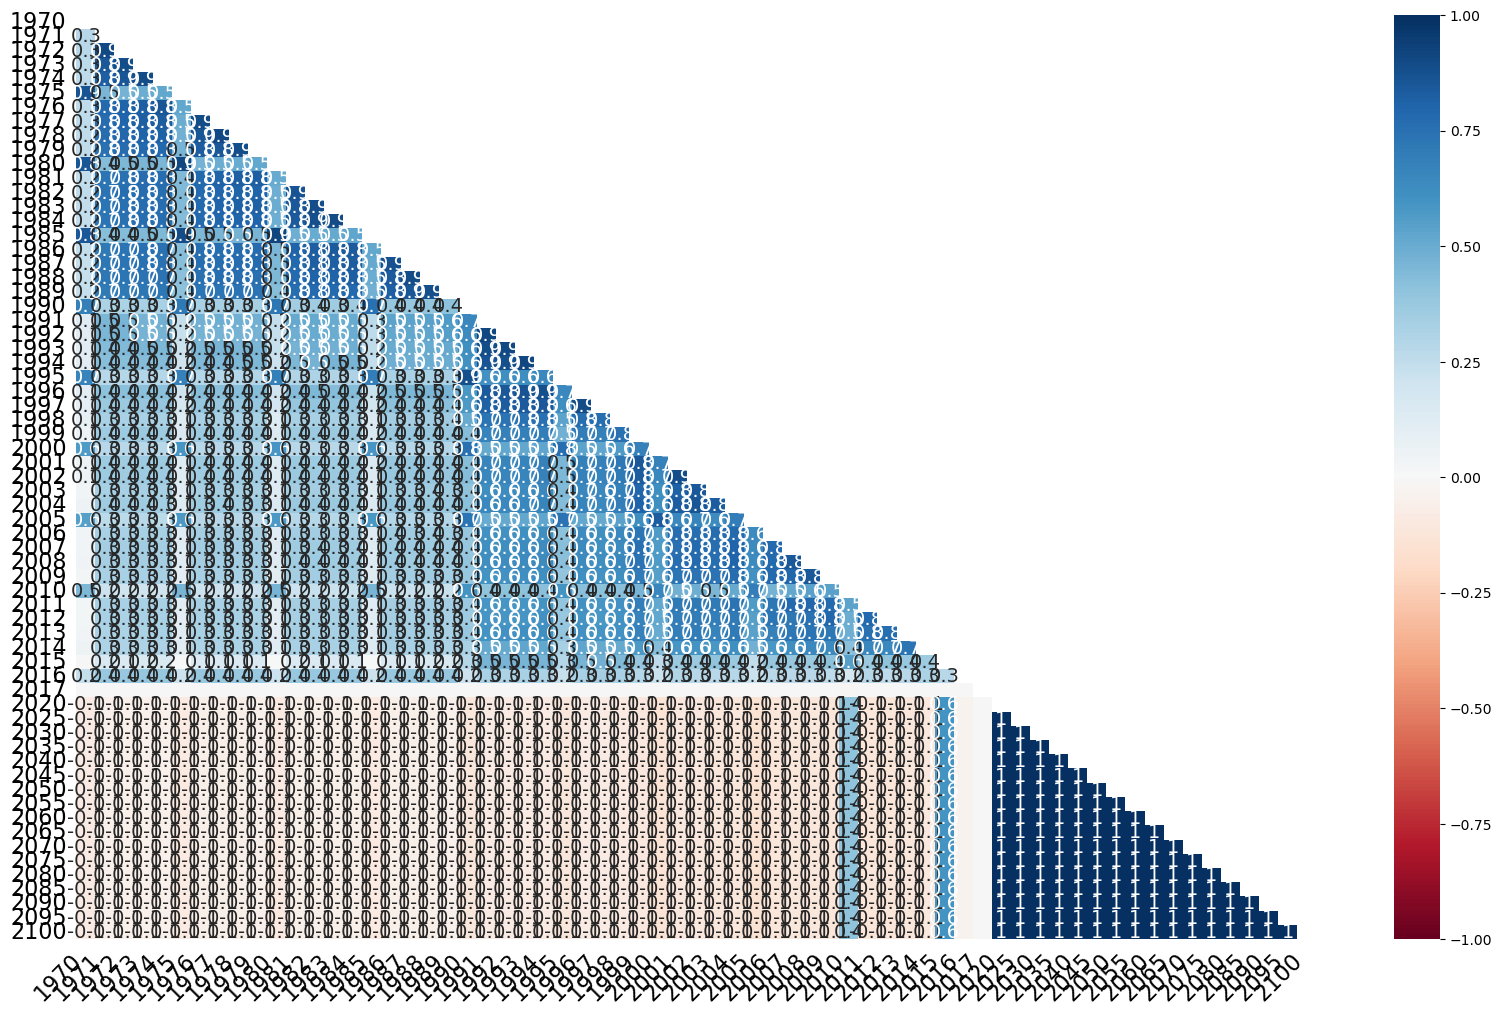

In [26]:
msno.heatmap(indicator_values)


['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2020', '2025', '2030', '2035', '2040', '2045', '2050', '2055', '2060', '2065', '2070', '2075', '2080', '2085', '2090', '2095', '2100', 'Unnamed: 69']


<Axes: >

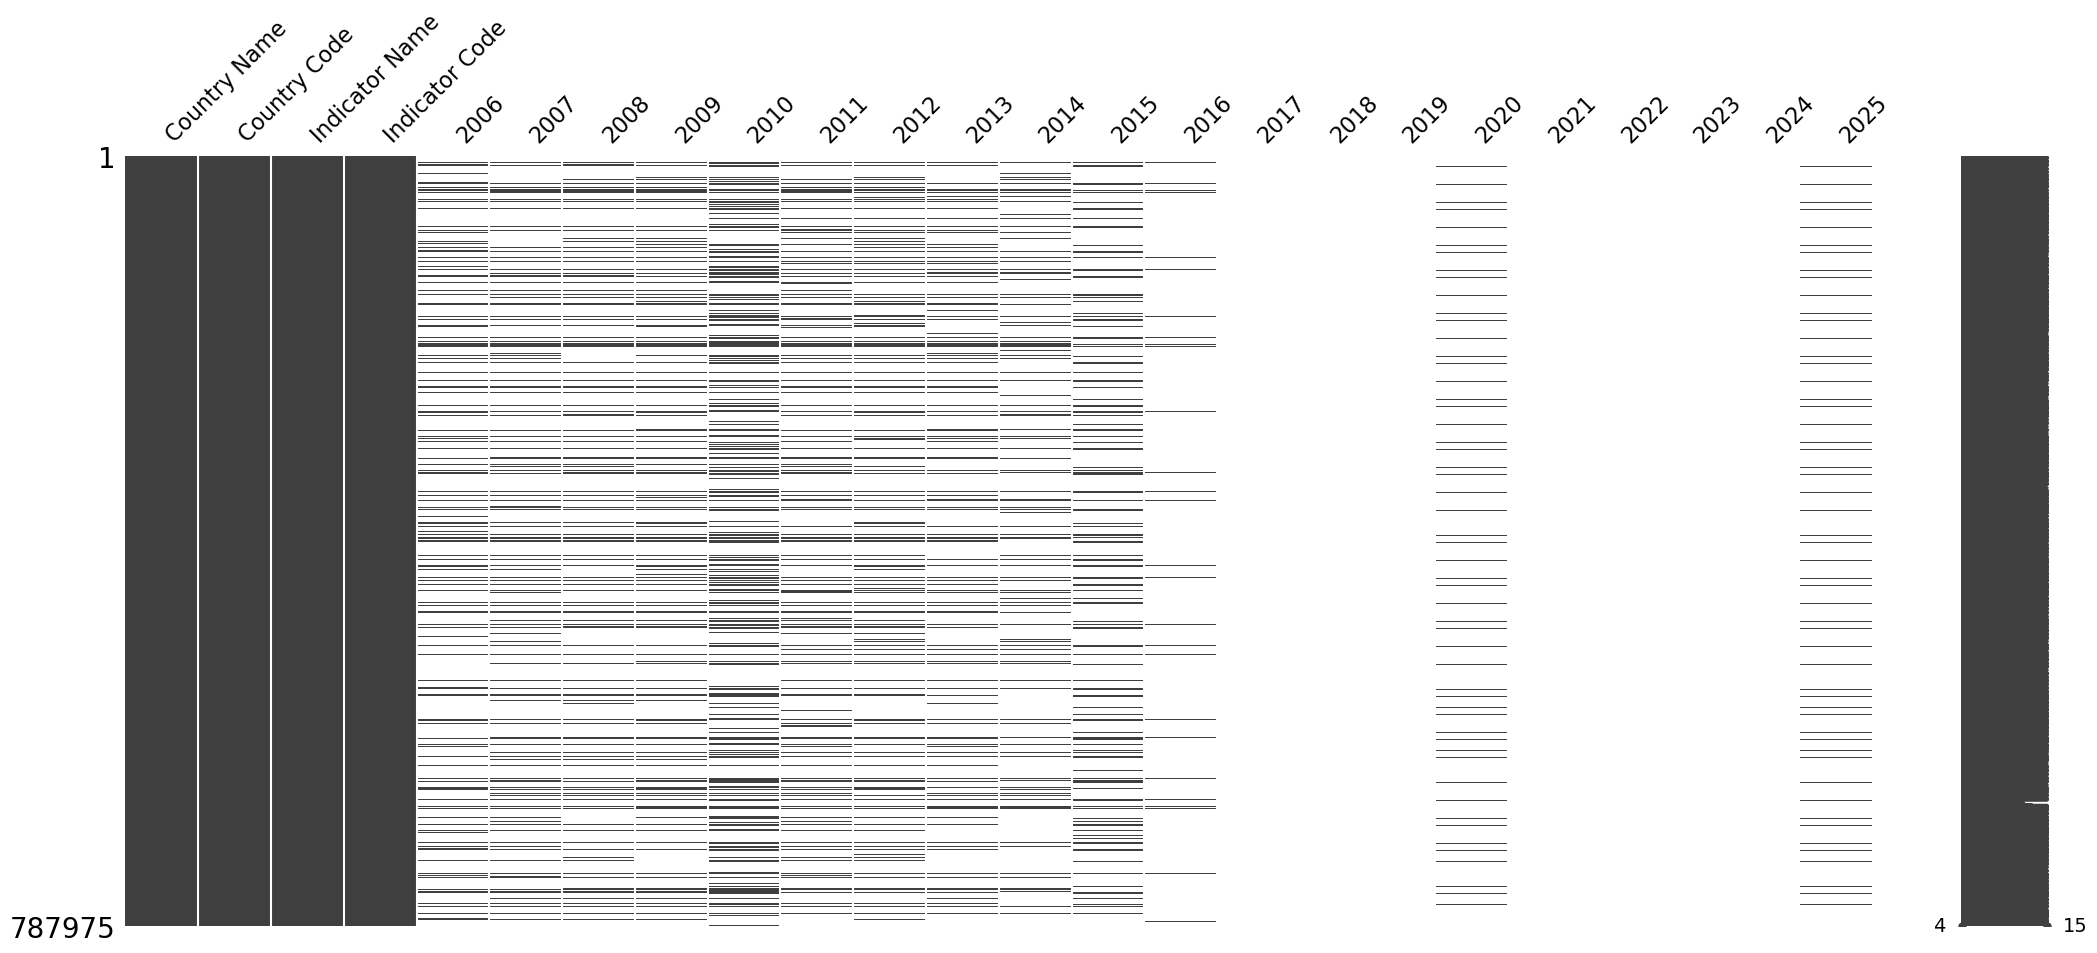

In [27]:
# First, check the actual columns in your DataFrame
available_columns = indicator_values.columns.tolist()
print(available_columns)


indicator_values[['2018', '2019', '2021','2022','2023','2024']]=np.nan

kept_columns = ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018','2019','2020','2021','2022','2023','2024','2025']



# This filters the DataFrame to keep only the specified columns
indicator_values = indicator_values[kept_columns]


msno.matrix(indicator_values)



In [28]:
final_columns = indicator_values.columns.tolist()
print(final_columns)

['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']


# seriescode_description D

"""


### Description
This table contains:
- **`country`**: Name or code of the country.
- **`series_code`**: Unique identifier for the indicator series.
- **`description`**: Likely a note about whether or how the series code applies to the country.


- This table is **irrelevant** for the current analysis, as it does not provide actionable or necessary information for the project's objectives.
- No further exploration of this file is required.
"""



In [29]:
seriescode_description = pd.read_csv('EdStatsCountrySeries.csv')
seriescode_description.head()

,CountryCode,SeriesCode,DESCRIPTION,Unnamed: 3
0,ABW,SP.POP.TOTL,Data sources : United Nations World Population...,NaN
1,ABW,SP.POP.GROW,Data sources: United Nations World Population ...,NaN
2,AFG,SP.POP.GROW,Data sources: United Nations World Population ...,NaN
3,AFG,NY.GDP.PCAP.PP.CD,Estimates are based on regression.,NaN
4,AFG,SP.POP.TOTL,Data sources : United Nations World Population...,NaN


In [30]:
seriescode_description.shape

(613, 4)

# country_characteristics D


"""


### Description
This table contains **country-level metadata**, including:
- **`country`**: Name or code of the country.
- **`currency`**: Official currency of the country.
- **`income_group`**: Classification of the country by income level (e.g., low-income, high-income).
- **`lending_category`**: Classification related to lending eligibility or terms.
- **`system_of_accounts`**: Accounting standards or systems used.
- **`survey_dates`**: Dates and explanations of surveys conducted (e.g., PPP surveys).

The table provides **characteristics of countries**, such as economic classifications and survey timelines.


- While the **`income_group`** variable is relevant.
- The `indicators_values` dataframe already includes all necessary indicator data, including PPP and technology-related metrics (e.g., internet and computer penetration).
"""
```

In [31]:
country_characteristics = pd.read_csv('EdStatsCountry.csv')
country_characteristics.head()

,Country Code,Short Name,Table Name,Long Name,2-alpha code,Currency Unit,Special Notes,Region,Income Group,WB-2 code,National accounts base year,National accounts reference year,SNA price valuation,Lending category,Other groups,System of National Accounts,Alternative conversion factor,PPP survey year,Balance of Payments Manual in use,External debt Reporting status,System of trade,Government Accounting concept,IMF data dissemination standard,Latest population census,Latest household survey,Source of most recent Income and expenditure data,Vital registration complete,Latest agricultural census,Latest industrial data,Latest trade data,Latest water withdrawal data,Unnamed: 31
0,ABW,Aruba,Aruba,Aruba,AW,Aruban florin,SNA data for 2000-2011 are updated from offici...,Latin America & Caribbean,High income: nonOECD,AW,2000,NaN,Value added at basic prices (VAB),NaN,NaN,Country uses the 1993 System of National Accou...,NaN,NaN,"IMF Balance of Payments Manual, 6th edition.",NaN,Special trade system,NaN,NaN,2010,NaN,NaN,Yes,NaN,NaN,2012.0,NaN,NaN
1,AFG,Afghanistan,Afghanistan,Islamic State of Afghanistan,AF,Afghan afghani,Fiscal year end: March 20; reporting period fo...,South Asia,Low income,AF,2002/03,NaN,Value added at basic prices (VAB),IDA,HIPC,Country uses the 1993 System of National Accou...,NaN,NaN,NaN,Actual,General trade system,Consolidated central government,General Data Dissemination System (GDDS),1979,"Multiple Indicator Cluster Survey (MICS), 2010/11","Integrated household survey (IHS), 2008",NaN,2013/14,NaN,2012.0,2000,NaN
2,AGO,Angola,Angola,People's Republic of Angola,AO,Angolan kwanza,"April 2013 database update: Based on IMF data,...",Sub-Saharan Africa,Upper middle income,AO,2002,NaN,Value added at producer prices (VAP),IBRD,NaN,Country uses the 1993 System of National Accou...,1991–96,2005,"IMF Balance of Payments Manual, 6th edition.",Actual,Special trade system,Budgetary central government,General Data Dissemination System (GDDS),1970,"Malaria Indicator Survey (MIS), 2011","Integrated household survey (IHS), 2008",NaN,2015,NaN,NaN,2005,NaN
3,ALB,Albania,Albania,Republic of Albania,AL,Albanian lek,NaN,Europe & Central Asia,Upper middle income,AL,Original chained constant price data are resca...,1996.0,Value added at basic prices (VAB),IBRD,NaN,Country uses the 1993 System of National Accou...,NaN,Rolling,"IMF Balance of Payments Manual, 6th edition.",Actual,General trade system,Budgetary central government,General Data Dissemination System (GDDS),2011,"Demographic and Health Survey (DHS), 2008/09",Living Standards Measurement Study Survey (LSM...,Yes,2012,2010.0,2012.0,2006,NaN
4,AND,Andorra,Andorra,Principality of Andorra,AD,Euro,NaN,Europe & Central Asia,High income: nonOECD,AD,1990,NaN,NaN,NaN,NaN,Country uses the 1968 System of National Accou...,NaN,NaN,NaN,NaN,Special trade system,NaN,NaN,2011. Population figures compiled from adminis...,NaN,NaN,Yes,NaN,NaN,2006.0,NaN,NaN


### Processing

Keep only the columns 'Country Code' and 'Income Group'

In [32]:
country_characteristics = country_characteristics[['Country Code','Income Group' ]]


# Merging Data
### Processing
- **Merge retained tables**: Combine data from all retained tables.
- **Merge keys**: Use **`Indicator Code`** and **`Country Code`** as the primary keys for merging.


In [33]:
#Merge all dataframes to acheive a consilidated table



consolidated_table = pd.merge(
    indicator_values,
    indicator_data,
    left_on='Indicator Code',  # Adjust this to match the actual column name in indicator_values
    right_on='Series Code', # Adjust this to match the actual column name in indicator_data
    how="inner"
)

consolidated_table.drop(columns=['Series Code', 'Indicator Name_y'], inplace=True)
consolidated_table.rename(columns={'Indicator Name_x': 'Indicator Name'}, inplace=True)

print(consolidated_table.shape)

consolidated_table = pd.merge(
    consolidated_table,
    country_characteristics,
    left_on='Country Code',  # Adjust this to match the actual column name in indicator_values
    right_on='Country Code', # Adjust this to match the actual column name in indicator_data
    how="left"
)

consolidated_table = consolidated_table[['Country Name', 'Country Code', 'Income Group', 'Indicator Name', 'Indicator Code', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']]
consolidated_table.head()

(3870, 24)


,Country Name,Country Code,Income Group,Indicator Name,Indicator Code,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Afghanistan,AFG,Low income,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,2.805987e+01,NaN,NaN,NaN,NaN,NaN,4.743679e+01,5.062723e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,Low income,"Adjusted net enrolment rate, upper secondary, ...",UIS.NERA.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.133262e+01,3.241703e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,Low income,"Enrolment in secondary general, both sexes (nu...",SE.SEC.ENRL.GC,NaN,1.028382e+06,1.415293e+06,1.693479e+06,2.032719e+06,2.190878e+06,2.392465e+06,2.508900e+06,2.577715e+06,2.671830e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,AFG,Low income,"Enrolment in tertiary education, all programme...",SE.TER.ENRL,NaN,NaN,NaN,9.518500e+04,NaN,9.750400e+04,NaN,NaN,2.628740e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,AFG,Low income,GDP at market prices (constant 2005 US$),NY.GDP.MKTP.KD,1.030523e+10,1.172119e+10,1.214448e+10,1.469733e+10,1.593680e+10,1.691113e+10,1.935220e+10,1.973134e+10,1.999032e+10,2.021272e+10,2.066392e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
consolidated_table.shape

(3870, 25)

# REFINING AND FINALIZING


### Processing
- Evaluate the **fill rates** for each selected indicator and for each year.
- Calculate the **average fill rate** across all years for each indicator.
- Drop all the indicators with **low fill rates**.

Post-Filtering
- Retain a **further restrained list of indicators** based on the fill rate analysis.
- Apply this filtered list to the **consolidated table** for further processing.

In [35]:
columns_to_check = [ '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']
 # columns for fill rate analysis
group_col = 'Indicator Name'               # column to group by

# -----------------------------
# Step 1: Fill rate per group
# -----------------------------
fill_rate_per_group = consolidated_table.groupby(group_col)[columns_to_check].apply(lambda g: g.notna().mean())

# Compute average fill rate per group
fill_rate_per_group['avg_fill_rate'] = fill_rate_per_group.mean(axis=1)

# Rank groups based on average fill rate
fill_rate_per_group['rank'] = fill_rate_per_group['avg_fill_rate'].rank(ascending=False, method='dense')

# Fixed line: removed the 'name' parameter which is not valid for DataFrame.reset_index()
fill_rate_per_group.reset_index().to_csv('fill_rate_per_group.csv', index=False)
print("Fill rate per indicator:\n", fill_rate_per_group)

# -----------------------------
# Step 3: Rank columns by fill rate
# -----------------------------
fill_rate_overall = consolidated_table[columns_to_check].notna().mean()

ranked_fill_rate = fill_rate_overall.rank(ascending=False, method='dense')
print("\nRanked fill rate per column:\n", ranked_fill_rate)

Fill rate per indicator:
                                                         2006      2007  \
Indicator Name                                                           
Adjusted net enrolment rate, lower secondary, b...  0.455814  0.483721   
Adjusted net enrolment rate, upper secondary, b...  0.186047  0.195349   
Enrolment in secondary general, both sexes (num...  0.734884  0.772093   
Enrolment in tertiary education, all programmes...  0.600000  0.600000   
GDP at market prices (constant 2005 US$)            0.916279  0.916279   
GDP at market prices (current US$)                  0.944186  0.939535   
GDP per capita (current US$)                        0.944186  0.939535   
Government expenditure on secondary education a...  0.358140  0.390698   
Government expenditure on tertiary education as...  0.409302  0.409302   
Government expenditure per secondary student (US$)  0.325581  0.358140   
Government expenditure per secondary student as...  0.316279  0.362791   
Government e

In [36]:
# List of indicators to keep
indicators = [
    'Enrolment in secondary general, both sexes (number)',
    'Enrolment in tertiary education, all programmes, both sexes (number)',
    'GDP at market prices (current US$)',
    'Government expenditure on secondary education as % of GDP (%)',
    'Government expenditure on tertiary education as % of GDP (%)',
    'Government expenditure per secondary student (US$)',
    'Government expenditure per tertiary student (US$)',
    'Internet users (per 100 people)'
]

# Filter the DataFrame
consolidated_table = consolidated_table[consolidated_table['Indicator Name'].isin(indicators)]
consolidated_table.shape

(1720, 25)

In [37]:
consolidated_table.head()

,Country Name,Country Code,Income Group,Indicator Name,Indicator Code,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
2,Afghanistan,AFG,Low income,"Enrolment in secondary general, both sexes (nu...",SE.SEC.ENRL.GC,NaN,1.028382e+06,1.415293e+06,1.693479e+06,2.032719e+06,2.190878e+06,2.392465e+06,2.508900e+06,2.577715e+06,2.671830e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,AFG,Low income,"Enrolment in tertiary education, all programme...",SE.TER.ENRL,NaN,NaN,NaN,9.518500e+04,NaN,9.750400e+04,NaN,NaN,2.628740e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Afghanistan,AFG,Low income,GDP at market prices (current US$),NY.GDP.MKTP.CD,7.057598e+09,9.843842e+09,1.019053e+10,1.248694e+10,1.593680e+10,1.793024e+10,2.053654e+10,2.004633e+10,2.005019e+10,1.921556e+10,1.946902e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Afghanistan,AFG,Low income,Government expenditure on secondary education ...,UIS.XGDP.23.FSGOV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Afghanistan,AFG,Low income,Government expenditure on tertiary education a...,UIS.XGDP.56.FSGOV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Correlation Analysis Preparation

### Processing 2
- **Melt the consolidated table**: Reshape the data to prepare for correlation analysis.
- **Compute Pearson correlation matrix**: Perform correlation analysis using the Pearson method.
- **Export correlation matrix**: Save the correlation matrix as a **flat file** for further analysis and indicator selection.


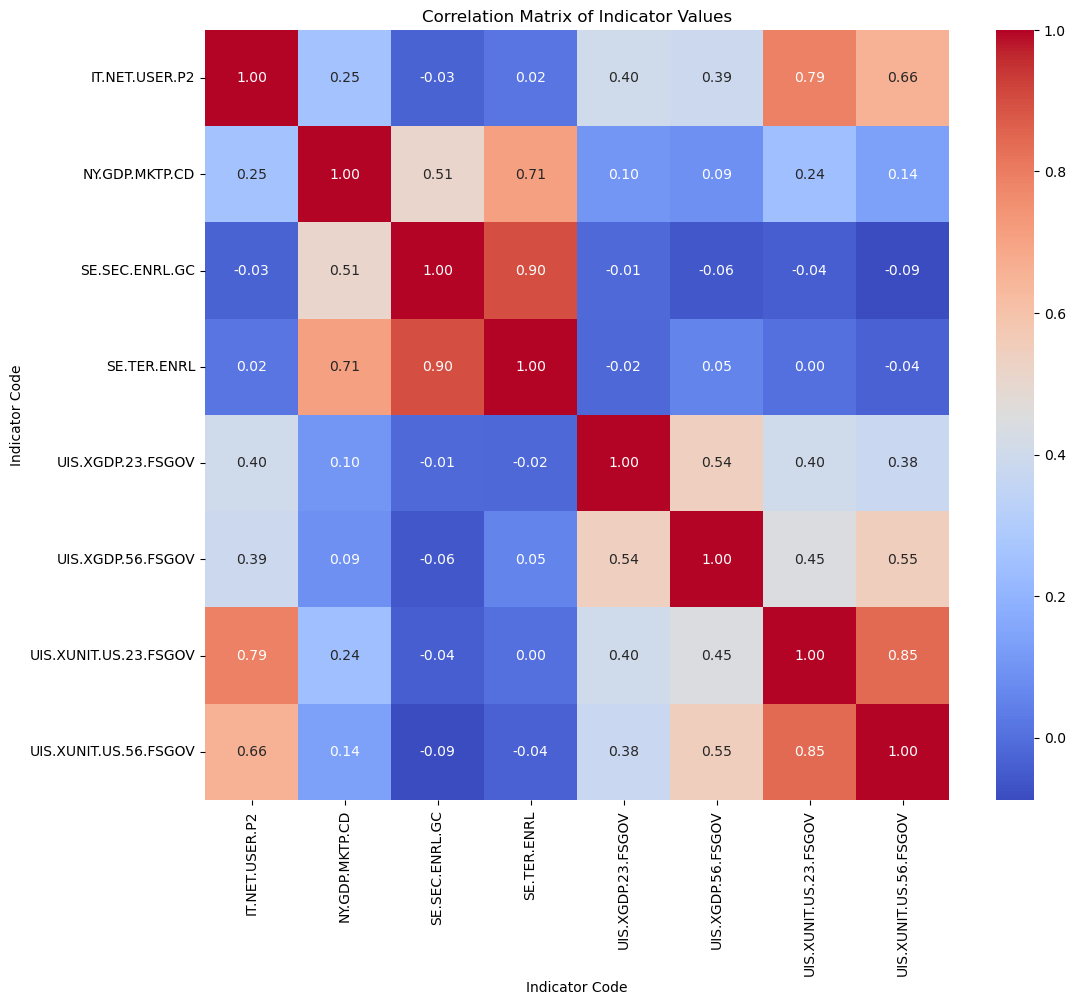

In [38]:
correlation_data = pd.melt(
   consolidated_table,
    id_vars=["Country Code", "Country Name","Income Group", "Indicator Code", "Indicator Name"],
    value_vars=['2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025'],
    var_name='Year',
    value_name='Value'
)

correlation_data = correlation_data [['Country Code','Indicator Code','Year','Value']]
correlation_data = correlation_data[correlation_data['Year'].isin(['2010', '2011', '2009', '2008'])]
correlation_data.head()

# Pivot to wide format: one column per year
correlation_data = correlation_data.pivot_table(
    index=["Country Code","Year"],
    columns= "Indicator Code",
    values="Value",
    aggfunc="mean"
)

# Reset the index to make "Country Code" and "Year" regular columns again
correlation_data = correlation_data.reset_index()
correlation_data.head()

correlation_data = correlation_data.drop(columns=['Country Code', 'Year'])

corr_matrix = correlation_data.corr(method='pearson')



plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Indicator Values")
plt.show()





In [39]:
import pandas as pd
import numpy as np
from pathlib import Path

# Adjust this to wherever your EdStats CSVs are stored
DATA_DIR = Path("data")   # <<-- change "data" if your EdStatsData.csv etc. are elsewhere

def build_flattened_correlation(consolidated_table: pd.DataFrame,
                                year_start: int | None = None,
                                year_end: int | None = None,
                                save_path: str | None = None):
    # 1) Detect year columns
    year_cols_all = [c for c in consolidated_table.columns if c.isdigit()]
    if not year_cols_all:
        raise ValueError("No year columns (as strings) found in consolidated_table.")

    # Optional year window
    if year_start is not None or year_end is not None:
        lo = year_start if year_start is not None else min(map(int, year_cols_all))
        hi = year_end if year_end is not None else max(map(int, year_cols_all))
        year_cols = [c for c in year_cols_all if lo <= int(c) <= hi]
    else:
        year_cols = year_cols_all

    if not year_cols:
        raise ValueError("No year columns left after applying the requested window.")

    # 2) Melt into long format
    melt = consolidated_table.melt(
        id_vars=[c for c in ["Country Code","Country Name","Indicator Code","Indicator Name"] if c in consolidated_table.columns],
        value_vars=year_cols,
        var_name="Year",
        value_name="Value"
    )

    # 3) Pivot to wide format (Indicator Code as unique columns)
    wide_code = melt.pivot_table(index=["Country Code","Year"], columns="Indicator Code",
                                 values="Value", aggfunc="mean")

    # 4) Impute missing values
    wide_code = wide_code.apply(lambda col: col.fillna(col.mean()), axis=0)

    # 5) Correlation
    corr_matrix = wide_code.corr(method="pearson")

    # 6) Map codes to friendly labels
    code_to_name = (melt.dropna(subset=["Indicator Code","Indicator Name"])
                        .drop_duplicates("Indicator Code")
                        .set_index("Indicator Code")["Indicator Name"]
                        .to_dict())
    friendly_cols = [f"{code_to_name.get(code, str(code))} ({code})" for code in corr_matrix.columns]
    corr_matrix.columns = friendly_cols
    corr_matrix.index = friendly_cols

    # 7) Flatten
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    upper = corr_matrix.where(mask)
    corr_flat_tbl = upper.stack().reset_index()
    corr_flat_tbl.columns = ["Indicator_1","Indicator_2","Correlation"]

    # 8) Sort by absolute correlation
    corr_flat_tbl = corr_flat_tbl.reindex(
        corr_flat_tbl["Correlation"].abs().sort_values(ascending=False).index
    ).reset_index(drop=True)

    # 9) Save in the same directory as the data, unless overridden
   

    return corr_matrix, corr_flat_tbl

# Example run
corr_matrix, corr_flat_table = build_flattened_correlation(
    consolidated_table,
    year_start=2008,
    year_end=2011
)



corr_flat_table.to_csv('corr_flat_table.csv', index=False)


In [40]:
consolidated_table.head()

,Country Name,Country Code,Income Group,Indicator Name,Indicator Code,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
2,Afghanistan,AFG,Low income,"Enrolment in secondary general, both sexes (nu...",SE.SEC.ENRL.GC,NaN,1.028382e+06,1.415293e+06,1.693479e+06,2.032719e+06,2.190878e+06,2.392465e+06,2.508900e+06,2.577715e+06,2.671830e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,AFG,Low income,"Enrolment in tertiary education, all programme...",SE.TER.ENRL,NaN,NaN,NaN,9.518500e+04,NaN,9.750400e+04,NaN,NaN,2.628740e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Afghanistan,AFG,Low income,GDP at market prices (current US$),NY.GDP.MKTP.CD,7.057598e+09,9.843842e+09,1.019053e+10,1.248694e+10,1.593680e+10,1.793024e+10,2.053654e+10,2.004633e+10,2.005019e+10,1.921556e+10,1.946902e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Afghanistan,AFG,Low income,Government expenditure on secondary education ...,UIS.XGDP.23.FSGOV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Afghanistan,AFG,Low income,Government expenditure on tertiary education a...,UIS.XGDP.56.FSGOV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Processing 3: Indicator Selection and Missing Value Treatment

### Processing
- **Select statistically relevant indicators**: Retain only the most statistically significant indicators from the correlation matrix for further analysis.

- **Analyze missing values**:
  - Use `missingno` to visualize and identify missing values in the consolidated table.

- **Impute missing values**:
  - Fill missing values using the **mean of available years** for each indicator and country.
  - Apply **interpolation and extrapolation** for missing values at the start or end of the year range.
  - **Constraint**: No imputation is performed for countries that never had data for a specific indicator.

---


<Axes: >

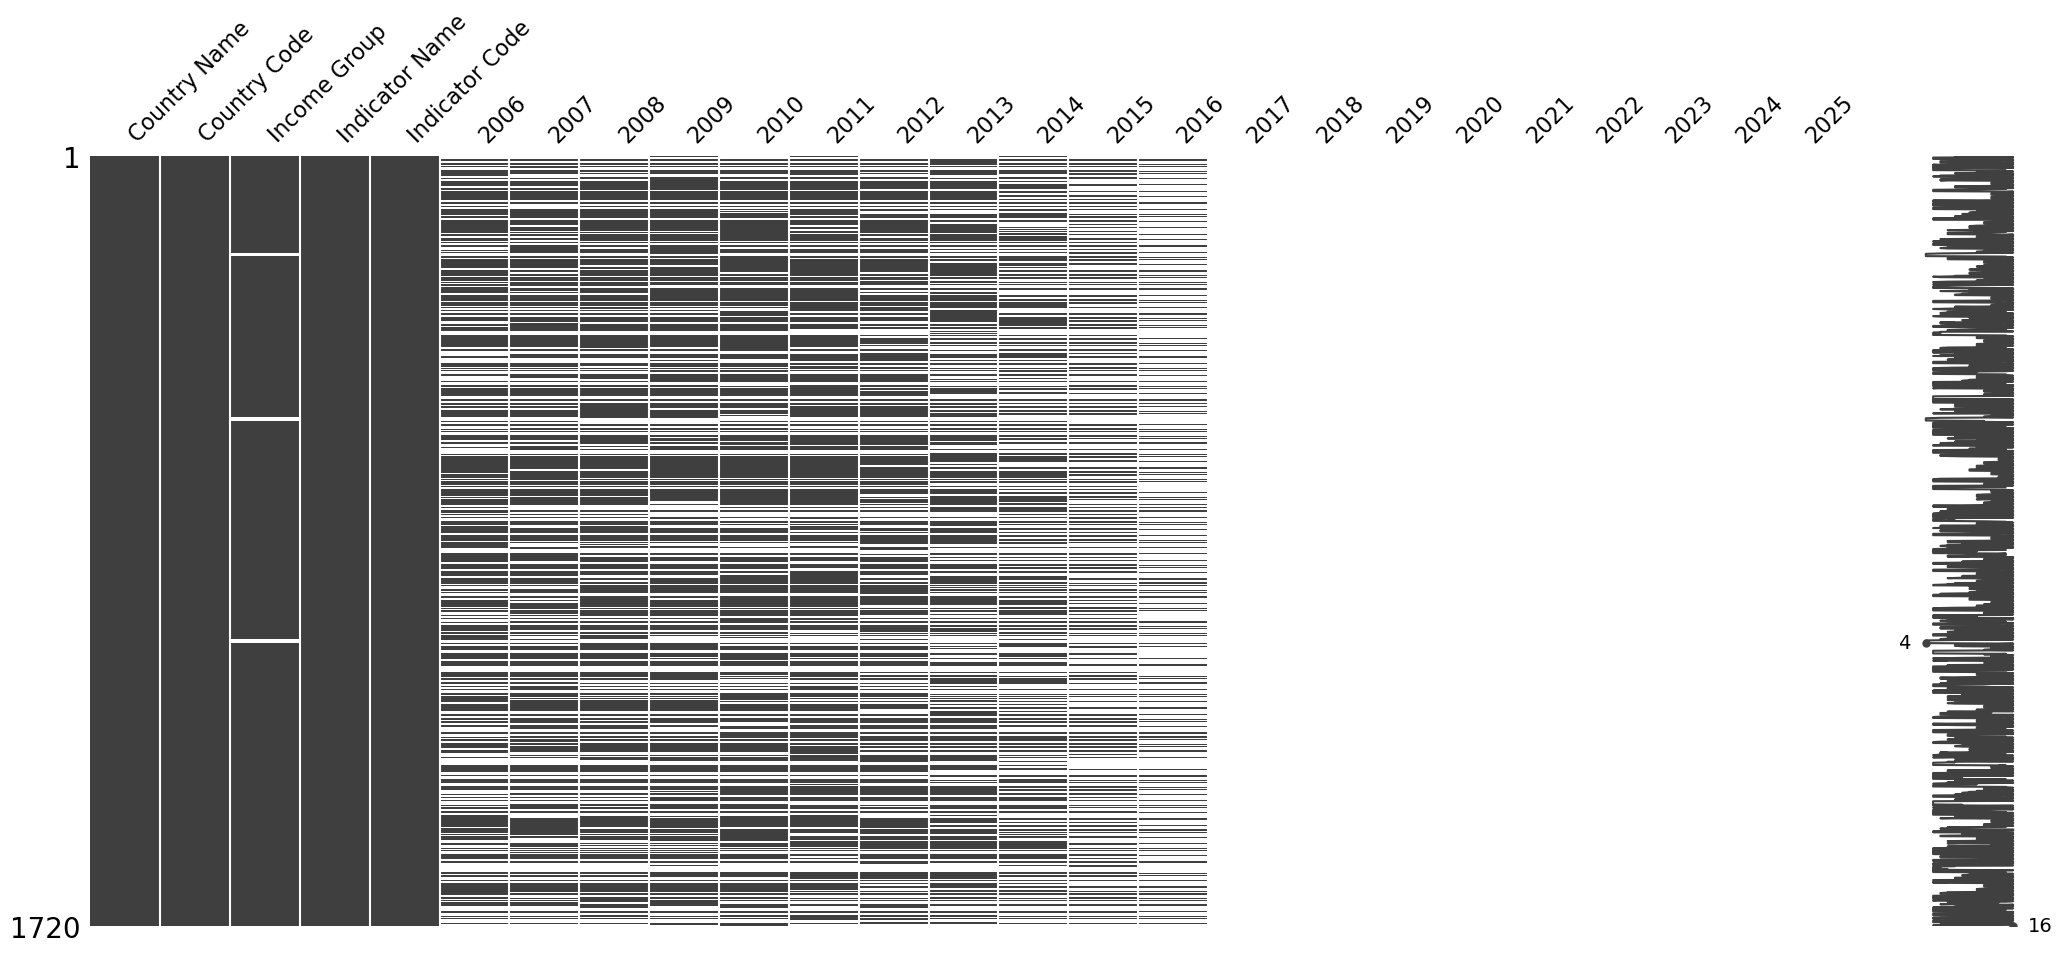

In [41]:
msno.matrix(consolidated_table)

<Axes: >

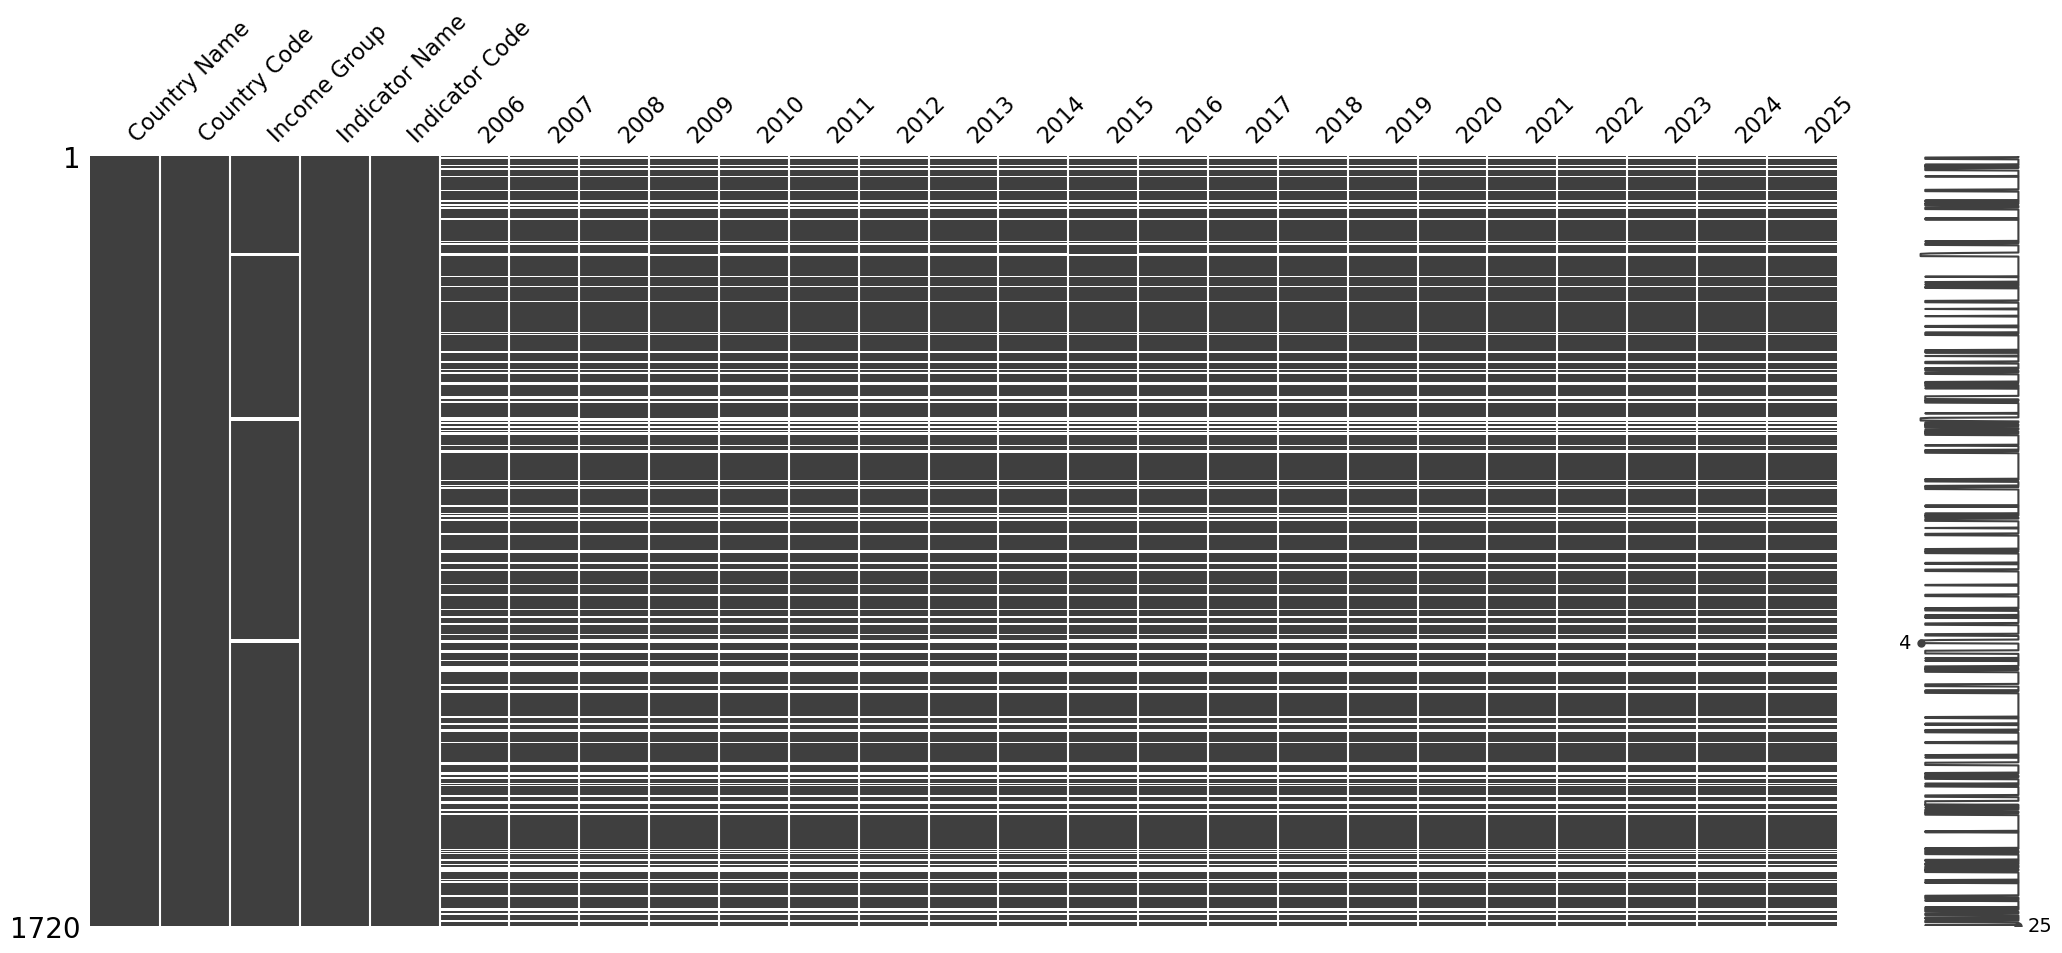

In [42]:
#fill missing values for indicators

# Identify the year columns
year_cols = [str(y) for y in range(2006, 2026)]

# Fill missing values per Country + Indicator
# Create a temporary DataFrame with the interpolated values
temp_df = consolidated_table.copy()  # Create a copy to work with

# Process each group separately and update the original DataFrame
for (country_code, country_name, income_group, indicator_code, indicator_name), group in consolidated_table.groupby([
    "Country Code", "Country Name","Income Group", "Indicator Code", "Indicator Name"
]):
    # Get the indices for this group
    idx = group.index
    
    # Interpolate the values for this group
    interpolated_values = (
        group[year_cols]
        .interpolate(axis=1, limit_direction='both')  # interpolate gaps
        .ffill(axis=1)                               # forward fill edge NaNs
        .bfill(axis=1)                              # backward fill edge NaNs
    )
    
    # Update the temporary DataFrame with interpolated values
    temp_df.loc[idx, year_cols] = interpolated_values

# Now assign the processed values back to the original DataFrame
consolidated_table[year_cols] = temp_df[year_cols]

# The code below should be outside the for loop and properly indented
# 1️⃣ Select only numeric columns
numeric_data = indicator_values.select_dtypes(include=['float', 'int'])


msno.matrix(consolidated_table)

# Processing 4: Weighted Indicator Summation

### Processing
- **Time range**: Use indicator values from **2006 to 2025** (after missing value imputation).

- **Assign incremental weights**:
  - Apply **year-based weights**, increasing incrementally from 2006 to 2025.
  - Normalize weights so their **sum equals 1** (2025 receives the highest weight, 2006 the lowest).

- **Calculate weighted sum**:
  - Compute a **weighted sum for each indicator**, emphasizing recent years (e.g., 2025 > 2006).

- **Final output**:
  - Retain only the **final weighted sum column** for each indicator.
  - Remove all intermediate year columns.


In [43]:
# Define years and linear weights
years = list(range(2006, 2026))
weights = np.arange(1, len(years) + 1)  # [1, 2, 3, ..., 20]
coefficients = weights / weights.sum()  # Normalize to sum=1

print("Before applying coefficients:")
print(consolidated_table[['Country Code', '2020']].head())

# Multiply each year column by its coefficient
for year, coef in zip(years, coefficients):
    consolidated_table[str(year)] = consolidated_table[str(year)] * coef

# Calculate the weighted mean for each row
year_columns = [str(year) for year in years]
consolidated_table['Indicator Weighted Sum'] = consolidated_table[year_columns].sum(axis=1)

# Print after
print("\nAfter applying coefficients:")
print(consolidated_table[['Country Code', '2020']].head())


Before applying coefficients:
  Country Code          2020
2          AFG  2.671830e+06
3          AFG  2.628740e+05
5          AFG  1.946902e+10
7          AFG           NaN
8          AFG           NaN

After applying coefficients:
  Country Code          2020
2          AFG  1.908450e+05
3          AFG  1.877671e+04
5          AFG  1.390644e+09
7          AFG           NaN
8          AFG           NaN


In [44]:
consolidated_table.head()

,Country Name,Country Code,Income Group,Indicator Name,Indicator Code,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,Indicator Weighted Sum
2,Afghanistan,AFG,Low income,"Enrolment in secondary general, both sexes (nu...",SE.SEC.ENRL.GC,4.897057e+03,9.794114e+03,2.021847e+04,3.225674e+04,4.839807e+04,6.259651e+04,7.974883e+04,9.557714e+04,1.104735e+05,1.272300e+05,1.399530e+05,1.526760e+05,1.653990e+05,1.781220e+05,1.908450e+05,2.035680e+05,2.162910e+05,2.290140e+05,2.417370e+05,2.544600e+05,2.563255e+06
3,Afghanistan,AFG,Low income,"Enrolment in tertiary education, all programme...",SE.TER.ENRL,4.532619e+02,9.065238e+02,1.359786e+03,1.813048e+03,2.293917e+03,2.785829e+03,5.087578e+03,7.914311e+03,1.126603e+04,1.251781e+04,1.376959e+04,1.502137e+04,1.627315e+04,1.752493e+04,1.877671e+04,2.002850e+04,2.128028e+04,2.253206e+04,2.378384e+04,2.503562e+04,2.404241e+05
5,Afghanistan,AFG,Low income,GDP at market prices (current US$),NY.GDP.MKTP.CD,3.360761e+07,9.375088e+07,1.455790e+08,2.378465e+08,3.794476e+08,5.122926e+08,6.845514e+08,7.636699e+08,8.592939e+08,9.150268e+08,1.019806e+09,1.112516e+09,1.205225e+09,1.297935e+09,1.390644e+09,1.483354e+09,1.576064e+09,1.668773e+09,1.761483e+09,1.854193e+09,1.899506e+10
7,Afghanistan,AFG,Low income,Government expenditure on secondary education ...,UIS.XGDP.23.FSGOV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00
8,Afghanistan,AFG,Low income,Government expenditure on tertiary education a...,UIS.XGDP.56.FSGOV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00


In [45]:

consolidated_table = consolidated_table[['Country Name',
 'Country Code',
 'Income Group',
 'Indicator Name',
 'Indicator Code',
 'Indicator Weighted Sum']]

consolidated_table ["ind concat"] = consolidated_table ['Indicator Code'] +"/" + consolidated_table['Indicator Name']
consolidated_table.head()

,Country Name,Country Code,Income Group,Indicator Name,Indicator Code,Indicator Weighted Sum,ind concat
2,Afghanistan,AFG,Low income,"Enrolment in secondary general, both sexes (nu...",SE.SEC.ENRL.GC,2.563255e+06,"SE.SEC.ENRL.GC/Enrolment in secondary general,..."
3,Afghanistan,AFG,Low income,"Enrolment in tertiary education, all programme...",SE.TER.ENRL,2.404241e+05,"SE.TER.ENRL/Enrolment in tertiary education, a..."
5,Afghanistan,AFG,Low income,GDP at market prices (current US$),NY.GDP.MKTP.CD,1.899506e+10,NY.GDP.MKTP.CD/GDP at market prices (current US$)
7,Afghanistan,AFG,Low income,Government expenditure on secondary education ...,UIS.XGDP.23.FSGOV,0.000000e+00,UIS.XGDP.23.FSGOV/Government expenditure on se...
8,Afghanistan,AFG,Low income,Government expenditure on tertiary education a...,UIS.XGDP.56.FSGOV,0.000000e+00,UIS.XGDP.56.FSGOV/Government expenditure on te...


# Processing Step 5: Pivot Table Construction and Cost Calculations

### Processing
- **Construct pivot table**:
  - Aggregate indicator values using the **mean** function.
  - Final pivot table includes:
    - `Country Code`
    - `Country Name`
    - All **selected indicators** as columns.
  - Result: **8 final indicators** retained for analysis.

- **Calculate education spending**:
  - **Method 1**:
    - Use indicators for **enrollment in tertiary and secondary education (as % of GDP)**.
    - Multiply by the country’s **GDP** to derive the **absolute monetary amount** spent on secondary and tertiary education.
  - **Method 2**:
    - Use indicators for:
      - Number of students enrolled in **secondary and tertiary education**.
      - Amount spent **per student** in secondary and tertiary education.
    - Multiply and sum to derive the **total monetary amount** spent.
  - **Final value**: Compute the **average** of the two methods to determine the total education spending.

- **Include additional indicator**:
  - Use **number of internet users per 100 people** as an additional metric for the final score.

---

# Processing Step 6: Normalization and Scoring

### Processing
- **Normalize indicators**:
  - Scale the **number of internet users per 100 people** to a **0–1 range** (base 100).
  - Scale the **total cost on secondary and tertiary education** to a normalized range (0–1).

- **Assign equal weights**:
  - Apply **equal weights** to both:
    - Normalized **total expenditure on education**.
    - Normalized **number of internet users**.
  - **Rationale**: The number of internet users is **critical** for assessing a country's potential.

- **Calculate final score**:
  - Sum the weighted normalized indicators.
  - Final score range: **0 to 2** (since each indicator has a maximum value of 1).

- **Sort by score**:
  - Rank countries based on the final score.
  - **Preliminary observation**: The **United States** appears to be the most relevant country based on this scoring.


In [46]:
consolidated_table = consolidated_table.pivot_table(
    index=['Country Code', 'Country Name'],
    columns='ind concat',
    values='Indicator Weighted Sum',
    aggfunc='mean'
).reset_index()

In [47]:
consolidated_table.head()

ind concat,Country Code,Country Name,IT.NET.USER.P2/Internet users (per 100 people),NY.GDP.MKTP.CD/GDP at market prices (current US$),"SE.SEC.ENRL.GC/Enrolment in secondary general, both sexes (number)","SE.TER.ENRL/Enrolment in tertiary education, all programmes, both sexes (number)",UIS.XGDP.23.FSGOV/Government expenditure on secondary education as % of GDP (%),UIS.XGDP.56.FSGOV/Government expenditure on tertiary education as % of GDP (%),UIS.XUNIT.US.23.FSGOV/Government expenditure per secondary student (US$),UIS.XUNIT.US.56.FSGOV/Government expenditure per tertiary student (US$)
0,ABW,Aruba,88.051012,2.582617e+09,7.480929e+03,1333.533333,0.000000,0.000000,0.000000,0.000000
1,AFG,Afghanistan,9.280698,1.899506e+10,2.563255e+06,240424.138889,0.000000,0.000000,0.000000,0.000000
2,AGO,Angola,11.428095,9.766135e+10,4.801353e+05,208592.659524,0.967890,0.198510,0.000000,2135.458984
3,ALB,Albania,62.357225,1.197119e+10,2.973168e+05,156548.428571,0.701640,0.775850,258.907440,573.089600
4,AND,Andorra,95.116222,2.978186e+09,3.961557e+03,498.414286,0.646428,0.173999,5005.375362,11666.178237


In [48]:
consolidated_table['Total cost on Secondary and Tertairy (Source: Numbers)'] =consolidated_table['SE.SEC.ENRL.GC/Enrolment in secondary general, both sexes (number)']*consolidated_table['UIS.XUNIT.US.23.FSGOV/Government expenditure per secondary student (US$)']+consolidated_table['SE.TER.ENRL/Enrolment in tertiary education, all programmes, both sexes (number)']*consolidated_table['UIS.XUNIT.US.56.FSGOV/Government expenditure per tertiary student (US$)']

In [49]:
consolidated_table['Total cost on Secondary and Tertairy (Source: Percentage)']= (consolidated_table['UIS.XGDP.23.FSGOV/Government expenditure on secondary education as % of GDP (%)']+consolidated_table['UIS.XGDP.56.FSGOV/Government expenditure on tertiary education as % of GDP (%)'])*consolidated_table['NY.GDP.MKTP.CD/GDP at market prices (current US$)']

In [50]:
consolidated_table = consolidated_table.rename(
    columns={'IT.NET.USER.P2/Internet users (per 100 people)': 'Internets Users'}
)

In [51]:
consolidated_table.head()

ind concat,Country Code,Country Name,Internets Users,NY.GDP.MKTP.CD/GDP at market prices (current US$),"SE.SEC.ENRL.GC/Enrolment in secondary general, both sexes (number)","SE.TER.ENRL/Enrolment in tertiary education, all programmes, both sexes (number)",UIS.XGDP.23.FSGOV/Government expenditure on secondary education as % of GDP (%),UIS.XGDP.56.FSGOV/Government expenditure on tertiary education as % of GDP (%),UIS.XUNIT.US.23.FSGOV/Government expenditure per secondary student (US$),UIS.XUNIT.US.56.FSGOV/Government expenditure per tertiary student (US$),Total cost on Secondary and Tertairy (Source: Numbers),Total cost on Secondary and Tertairy (Source: Percentage)
0,ABW,Aruba,88.051012,2.582617e+09,7.480929e+03,1333.533333,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00
1,AFG,Afghanistan,9.280698,1.899506e+10,2.563255e+06,240424.138889,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00
2,AGO,Angola,11.428095,9.766135e+10,4.801353e+05,208592.659524,0.967890,0.198510,0.000000,2135.458984,4.454411e+08,1.139122e+11
3,ALB,Albania,62.357225,1.197119e+10,2.973168e+05,156548.428571,0.701640,0.775850,258.907440,573.089600,1.666938e+08,1.768732e+10
4,AND,Andorra,95.116222,2.978186e+09,3.961557e+03,498.414286,0.646428,0.173999,5005.375362,11666.178237,2.564367e+07,2.443382e+09


In [52]:
consolidated_table = consolidated_table[['Country Code',
 'Country Name',
 'Internets Users', 'Total cost on Secondary and Tertairy (Source: Percentage)','Total cost on Secondary and Tertairy (Source: Numbers)']]

In [53]:
consolidated_table.head()

ind concat,Country Code,Country Name,Internets Users,Total cost on Secondary and Tertairy (Source: Percentage),Total cost on Secondary and Tertairy (Source: Numbers)
0,ABW,Aruba,88.051012,0.000000e+00,0.000000e+00
1,AFG,Afghanistan,9.280698,0.000000e+00,0.000000e+00
2,AGO,Angola,11.428095,1.139122e+11,4.454411e+08
3,ALB,Albania,62.357225,1.768732e+10,1.666938e+08
4,AND,Andorra,95.116222,2.443382e+09,2.564367e+07


In [54]:
# Calculate the average of the two columns
consolidated_table['Total Cost on Secondary and Tertiary (Numbers and %)'] = (
    consolidated_table['Total cost on Secondary and Tertairy (Source: Percentage)'] +
    consolidated_table['Total cost on Secondary and Tertairy (Source: Numbers)']
) / 2

# Calculate the absolute delta (percentage difference)
consolidated_table['delta (Numbers and %)'] = abs(
    (consolidated_table['Total cost on Secondary and Tertairy (Source: Percentage)'] -
     consolidated_table['Total cost on Secondary and Tertairy (Source: Numbers)']) /
    consolidated_table['Total Cost on Secondary and Tertiary (Numbers and %)'] 
)



In [55]:
consolidated_table.head()

ind concat,Country Code,Country Name,Internets Users,Total cost on Secondary and Tertairy (Source: Percentage),Total cost on Secondary and Tertairy (Source: Numbers),Total Cost on Secondary and Tertiary (Numbers and %),delta (Numbers and %)
0,ABW,Aruba,88.051012,0.000000e+00,0.000000e+00,0.000000e+00,NaN
1,AFG,Afghanistan,9.280698,0.000000e+00,0.000000e+00,0.000000e+00,NaN
2,AGO,Angola,11.428095,1.139122e+11,4.454411e+08,5.717882e+10,1.984419
3,ALB,Albania,62.357225,1.768732e+10,1.666938e+08,8.927005e+09,1.962654
4,AND,Andorra,95.116222,2.443382e+09,2.564367e+07,1.234513e+09,1.958455


In [56]:
consolidated_table.columns.to_list()
consolidated_table= consolidated_table[['Country Code',
 'Country Name',
 'Internets Users',
 'Total Cost on Secondary and Tertiary (Numbers and %)',
 'delta (Numbers and %)']]
consolidated_table.head()

ind concat,Country Code,Country Name,Internets Users,Total Cost on Secondary and Tertiary (Numbers and %),delta (Numbers and %)
0,ABW,Aruba,88.051012,0.000000e+00,NaN
1,AFG,Afghanistan,9.280698,0.000000e+00,NaN
2,AGO,Angola,11.428095,5.717882e+10,1.984419
3,ALB,Albania,62.357225,8.927005e+09,1.962654
4,AND,Andorra,95.116222,1.234513e+09,1.958455


In [57]:
# score to calculate a single measure with weightage of 0.3 for internet users indicator and 1 for the expenditure.

consolidated_table['Score'] = (0.3*consolidated_table['Internets Users']/100 + consolidated_table['Total Cost on Secondary and Tertiary (Numbers and %)']/max(consolidated_table['Total Cost on Secondary and Tertiary (Numbers and %)']))/1.3

In [58]:
consolidated_table.head()


ind concat,Country Code,Country Name,Internets Users,Total Cost on Secondary and Tertiary (Numbers and %),delta (Numbers and %),Score
0,ABW,Aruba,88.051012,0.000000e+00,NaN,0.203195
1,AFG,Afghanistan,9.280698,0.000000e+00,NaN,0.021417
2,AGO,Angola,11.428095,5.717882e+10,1.984419,0.027915
3,ALB,Albania,62.357225,8.927005e+09,1.962654,0.144142
4,AND,Andorra,95.116222,1.234513e+09,1.958455,0.219532


In [59]:
consolidated_table = consolidated_table[
    ['Country Code', 'Country Name','Total Cost on Secondary and Tertiary (Numbers and %)','delta (Numbers and %)', 'Score']
].sort_values(
    by='Score',  # Use `=` not `:`
    ascending=False  # No colon, just `=`
)

consolidated_table.rename(columns={'Total Cost on Secondary and Tertiary (Numbers and %)': 'Secondary and Tertiary Education Cost(Real)'}, inplace=True)
consolidated_table.rename(columns={'delta (Numbers and %)': 'Uncertainity on Cost'}, inplace=True)


consolidated_table.head(20)

ind concat,Country Code,Country Name,Secondary and Tertiary Education Cost(Real),Uncertainity on Cost,Score
202,USA,United States,2.852105e+13,1.967324,0.942921
49,DEU,Germany,6.088380e+12,1.980471,0.367140
97,JPN,Japan,5.558671e+12,1.957055,0.357126
67,GBR,United Kingdom,4.900325e+12,1.968488,0.346358
63,FRA,France,4.685921e+12,1.962554,0.320100
32,CAN,Canada,2.466593e+12,1.981784,0.270163
104,KOR,"Korea, Rep.",1.796918e+12,1.968986,0.257787
143,NLD,Netherlands,1.555005e+12,1.966497,0.251125
10,AUS,Australia,1.936888e+12,1.959328,0.250844
144,NOR,Norway,8.418829e+11,1.955107,0.245380


In [60]:
consolidated_table.style.format({
    'Secondary and Tertiary Education Cost(Real)': '${:.2f}M'  # Formats values as $XX.XXM
})
consolidated_table.head(20)

ind concat,Country Code,Country Name,Secondary and Tertiary Education Cost(Real),Uncertainity on Cost,Score
202,USA,United States,2.852105e+13,1.967324,0.942921
49,DEU,Germany,6.088380e+12,1.980471,0.367140
97,JPN,Japan,5.558671e+12,1.957055,0.357126
67,GBR,United Kingdom,4.900325e+12,1.968488,0.346358
63,FRA,France,4.685921e+12,1.962554,0.320100
32,CAN,Canada,2.466593e+12,1.981784,0.270163
104,KOR,"Korea, Rep.",1.796918e+12,1.968986,0.257787
143,NLD,Netherlands,1.555005e+12,1.966497,0.251125
10,AUS,Australia,1.936888e+12,1.959328,0.250844
144,NOR,Norway,8.418829e+11,1.955107,0.245380


graphique